<a href="https://colab.research.google.com/github/Shazebgk/Advanced_regression_Assignment/blob/main/Shazebk_Master_Final_Submission_CNN_Skin_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem statement: To build a CNN based model which can accurately detect melanoma. Melanoma is a type of cancer that can be deadly if not detected early. It accounts for 75% of skin cancer deaths. A solution which can evaluate images and alert the dermatologists about the presence of melanoma has the potential to reduce a lot of manual effort needed in diagnosis.

### Importing Skin Cancer Data
#### To do: Take necessary actions to read the data

### Importing all the important libraries

In [ ]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## Using the data by mounting the google drive:
from google.colab import drive
drive.mount('/SkinImaging', force_remount=True)

Mounted at /SkinImaging


This assignment uses a dataset of about 2357 images of skin cancer types. The dataset contains 9 sub-directories in each train and test subdirectories. The 9 sub-directories contains the images of 9 skin cancer types respectively.

In [ ]:
# Defining the path for train and test images
data_dir_train = pathlib.Path('/SkinImaging/MyDrive/SkinImaging/Train')
data_dir_test = pathlib.Path('/SkinImaging/MyDrive/SkinImaging/Test')

In [ ]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

2248
117


### Load using keras.preprocessing

Let's load these images off disk using the helpful image_dataset_from_directory utility.

### Create a dataset

Define some parameters for the loader:

In [ ]:
batch_size = 32
img_height = 180
img_width = 180

Use 80% of the images for training, and 20% for validation.

In [ ]:
# Creating a dataset from the pictures in the training folder so the computer can learn from them.

import tensorflow as tf

# Path to your training data directory
data_dir_train = '/SkinImaging/MyDrive/SkinImaging/Train'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train,
    labels='inferred',
    label_mode='categorical',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 2248 files belonging to 9 classes.


In [ ]:
# Creating a dataset from the pictures in the test folder so we can check how well the computer learned.

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_test,
    labels='inferred',
    label_mode='categorical',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 117 files belonging to 9 classes.


In [ ]:

# We are finding out the names of all the categories (types) of skin images in our training dataset.
# This code gets and stores the names of all the skin cancer classes from the training dataset so we can use them to label predictions or display class information.
# You can find the class names in the class_names attribute on these datasets.
# These correspond to the directory names in alphabetical order.

class_names = train_ds.class_names
skin_cancer_classes = list(class_names)
skin_cancer_classes


['actinic keratosis',
 'basal cell carcinoma',
 'dermatofibroma',
 'melanoma',
 'nevus',
 'pigmented benign keratosis',
 'seborrheic keratosis',
 'squamous cell carcinoma',
 'vascular lesion']

### Visualize the data
#### Code to visualize one instance of all the nine classes present in the dataset

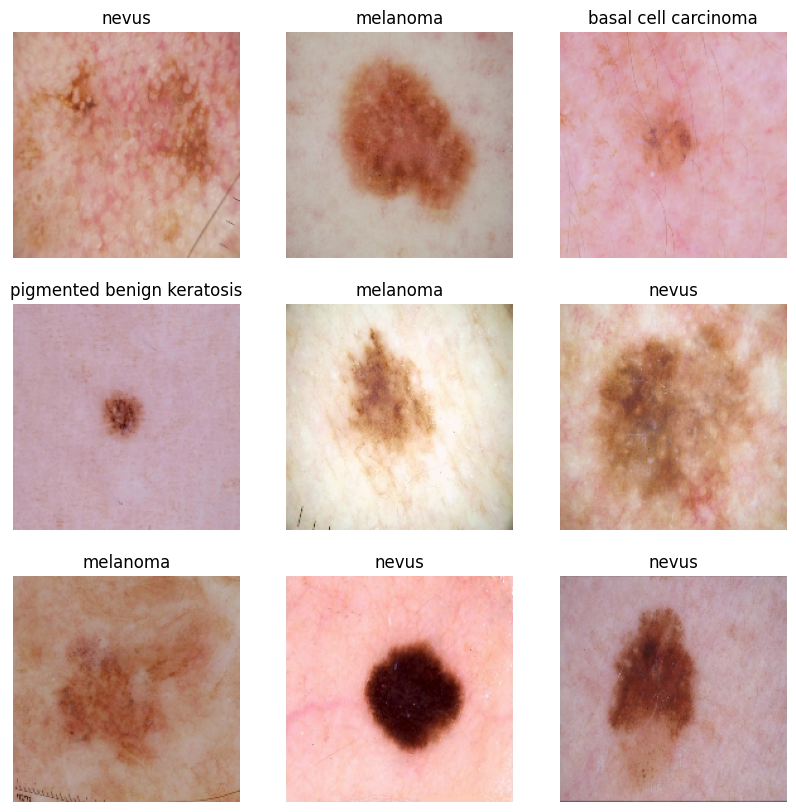

In [ ]:
# Displays 9 sample images from your training dataset with their class names

class_names = train_ds.class_names
skin_cancer_classes = list(class_names)


plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    # skin_cancer_classes is now defined in the current scope
    plt.title(skin_cancer_classes[np.argmax(labels[i])])

    plt.axis("off")

The `image_batch` is a tensor of the shape `(32, 180, 180, 3)`. This is a batch of 32 images of shape `180x180x3` (the last dimension refers to color channels RGB). The `label_batch` is a tensor of the shape `(32,)`, these are corresponding labels to the 32 images.

`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.

`Dataset.prefetch()` overlaps data preprocessing and model execution while training.

In [ ]:
# To make loading and feeding images to the computer faster and smoother
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Create the model
#### Creating a CNN model, which can accurately detect 9 classes present in the dataset.

In [ ]:
# Create a neural network (computer brain) to recognize skin cancer imagesfrom tensorflow import keras
from tensorflow.keras import layers
# Import the preprocessing layer directly
from tensorflow.keras.layers import Rescaling

num_classes = 9

model = keras.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)), # Use Rescaling directly
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compile the model


In [ ]:
# Prepare the neural network for learning
model.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
# To show a summary of your neural network
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,801 (15.22 MB)

 Trainable params: 3,989,801 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [ ]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 417s 638ms/step - accuracy: 0.2378 - loss: 2.0679 - val_accuracy: 0.1368 - val_loss: 2.3234
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.3861 - loss: 1.6880 - val_accuracy: 0.3846 - val_loss: 2.4627
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5066 - loss: 1.4451 - val_accuracy: 0.3248 - val_loss: 2.1965
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5678 - loss: 1.2805 - val_accuracy: 0.2906 - val_loss: 2.5362
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5495 - loss: 1.3029 - val_accuracy: 0.3419 - val_loss: 2.3795
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5636 - loss: 1.1975 - val_accuracy: 0.3504 - val_loss: 2.2032
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6090 - loss: 1.1049 - val_accuracy: 0.3333 - val_loss: 2.9852
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6365 - loss: 1.0299 - val_accuracy: 0.3162

### Visualizing training results

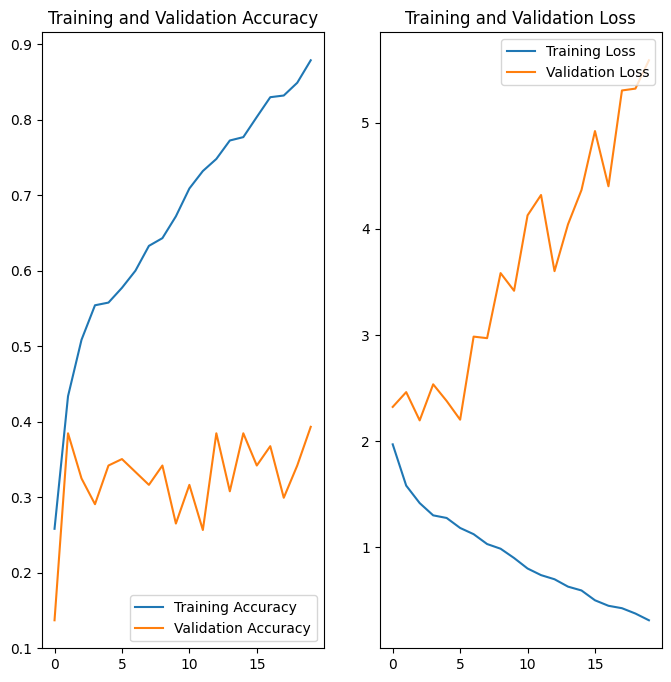

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Todo: Write your findings after the model fit, see if there is an evidence of model overfit or underfit

### Write your findings here

Evidence of Overfitting: Means it works well on the training dataset but fails to correctly identify skin cancer types in new images.
What the graph shows:

Training Accuracy (blue line, left graph):
Keeps going up, reaching above 85%.
This means the model is learning the training data very well.

Validation Accuracy (orange line, left graph):
Stays low around 30–40% and doesn’t improve.
This means the model is not doing well on unseen/test data.

Training Loss (blue line, right graph):
Keeps going down, close to 0.
Model is memorizing the training set.

Validation Loss (orange line, right graph):
Keeps going up sharply.
Model is getting worse on unseen data.



In [ ]:

# Analyze the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Check for overfitting
if val_acc[-1] < acc[-1] and val_loss[-1] > loss[-1]:
  print("Evidence of overfitting. Validation accuracy is lower than training accuracy and validation loss is higher than training loss.")
  # Data Augmentation Strategy for Overfitting:
  # Apply random transformations to the training images to increase the variability of the training data.
  # This helps the model generalize better to unseen data.
  data_augmentation = keras.Sequential(
      [
          layers.RandomFlip("horizontal",
                            input_shape=(img_height,
                                        img_width,
                                        3)),
          layers.RandomRotation(0.1),
          layers.RandomZoom(0.1),
      ]
  )

  # Re-train model with data augmentation
  model = Sequential([
      data_augmentation, # add data augmentation layer here
      layers.Rescaling(1./255), # Removed 'experimental.preprocessing'
      layers.Conv2D(16, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(32, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(num_classes, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss=tf.keras.losses.CategoricalCrossentropy(),
                metrics=['accuracy'])

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
  )

elif val_acc[-1] < 0.8 and val_loss[-1] > 0.5: # Example threshold for underfitting. Adjust as needed
  print("Evidence of underfitting. Validation accuracy and/or validation loss indicates poor performance.")
  # Data Augmentation Strategy for Underfitting:
  # Increase model complexity or the amount of training data.
  # Adding more layers, increasing the number of filters, or training for more epochs are good options.
  # Data augmentation might be less helpful here unless you are seriously data starved.

  # Example: increase number of filters and add another convolutional block. Retrain the model.
  model = Sequential([
      layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)), # Removed 'experimental.preprocessing'
      layers.Conv2D(32, 3, padding='same', activation='relu'),  # Increased filters
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(128, 3, padding='same', activation='relu'), # Added another conv block
      layers.MaxPooling2D(),
      layers.Flatten(),
      layers.Dense(256, activation='relu'), # Increased Dense layer units
      layers.Dense(num_classes, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss=tf.keras.losses.CategoricalCrossentropy(),
                metrics=['accuracy'])

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
  )


else:
  print("Model seems to be")

Evidence of overfitting. Validation accuracy is lower than training accuracy and validation loss is higher than training loss.
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.1967 - loss: 2.1832 - val_accuracy: 0.1966 - val_loss: 2.1677
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3875 - loss: 1.7012 - val_accuracy: 0.3248 - val_loss: 2.2552
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4634 - loss: 1.5138 - val_accuracy: 0.3504 - val_loss: 2.0213
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5058 - loss: 1.4145 - val_accuracy: 0.3761 - val_loss: 2.1400
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5085 - loss: 1.4024 - val_accuracy: 0.3419 - val_loss: 2.4375
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5356 - loss: 1.3098 - val_accuracy: 0.3333 - val_loss: 1.9622
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5467 - loss: 1.2617 - val_accuracy: 0.3932 - v

Found 2248 files belonging to 9 classes.


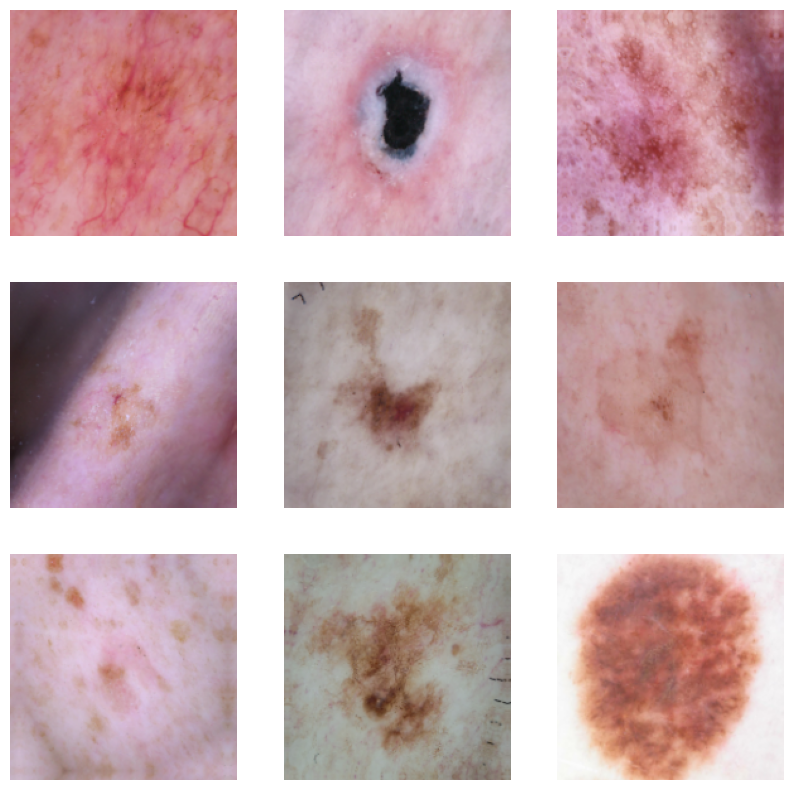

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load images from the directory into a TensorFlow dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir_train,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True
)

# Iterate through the dataset to get images
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1): # use train_ds instead of data_dir_train
  for i in range(9):
    augmented_image = data_augmentation(images[i:i+1]) # augment a single image

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.axis("off")
plt.show()

### Todo:
### Create the model, compile and train the model


In [ ]:

# Assuming the model, compile, and training code from the previous response is already executed.
# This code snippet addresses the TODO items and potential overfitting/underfitting issues.

from tensorflow import keras
from tensorflow.keras import layers


# Analyze the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Check for overfitting
if val_acc[-1] < acc[-1] and val_loss[-1] > loss[-1]:
  print("Evidence of overfitting. Validation accuracy is lower than training accuracy and validation loss is higher than training loss.")
  # Data Augmentation Strategy for Overfitting:
  # Apply random transformations to the training images to increase the variability of the training data.
  # This helps the model generalize better to unseen data.
  data_augmentation = keras.Sequential(
      [
          layers.RandomFlip("horizontal",
                            input_shape=(img_height,
                                        img_width,
                                        3)),
          layers.RandomRotation(0.1),
          layers.RandomZoom(0.1),
      ]
  )

  # Re-train model with data augmentation
  model = Sequential([
      data_augmentation, # add data augmentation layer here
      layers.Rescaling(1./255),
      layers.Conv2D(16, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(32, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(num_classes, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss=tf.keras.losses.CategoricalCrossentropy(),
                metrics=['accuracy'])

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
  )

elif val_acc[-1] < 0.8 and val_loss[-1] > 0.5: # Example threshold for underfitting. Adjust as needed
  print("Evidence of underfitting. Validation accuracy and/or validation loss indicates poor performance.")
  # Data Augmentation Strategy for Underfitting:
  # Increase model complexity or the amount of training data.
  # Adding more layers, increasing the number of filters, or training for more epochs are good options.
  # Data augmentation might be less helpful here unless you are seriously data starved.

  # Example: increase number of filters and add another convolutional block. Retrain the model.
  model = Sequential([
      layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
      layers.Conv2D(32, 3, padding='same', activation='relu'),  # Increased filters
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(128, 3, padding='same', activation='relu'), # Added another conv block
      layers.MaxPooling2D(),
      layers.Flatten(),
      layers.Dense(256, activation='relu'), # Increased Dense layer units
      layers.Dense(num_classes, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss=tf.keras.losses.CategoricalCrossentropy(),
                metrics=['accuracy'])

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
  )


else:
  print("Model seems to be performing well.")

Evidence of overfitting. Validation accuracy is lower than training accuracy and validation loss is higher than training loss.
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 242ms/step - accuracy: 0.2190 - loss: 2.3815 - val_accuracy: 0.1795 - val_loss: 2.2305
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step - accuracy: 0.3571 - loss: 1.8085 - val_accuracy: 0.2991 - val_loss: 2.2333
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 246ms/step - accuracy: 0.4696 - loss: 1.5099 - val_accuracy: 0.3419 - val_loss: 2.3405
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.4944 - loss: 1.3873 - val_accuracy: 0.3504 - val_loss: 2.0730
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 260ms/step - accuracy: 0.5217 - loss: 1.3471 - val_accuracy: 0.3504 - val_loss: 2.2612
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 242ms/step - accuracy: 0.5723 - loss: 1.2341 - val_accuracy: 0.3932 - val_loss: 2.0949
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.5530 - loss: 1.2418 - val_accura

### Compiling the model

In [ ]:
# Assuming the model, compile, and training code from the previous response is already executed.
# This code snippet addresses the TODO items and potential overfitting/underfitting issues.

# Analyze the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Check for overfitting
if val_acc[-1] < acc[-1] and val_loss[-1] > loss[-1]:
  print("Evidence of overfitting. Validation accuracy is lower than training accuracy and validation loss is higher than training loss.")
  # Data Augmentation Strategy for Overfitting:
  # Apply random transformations to the training images to increase the variability of the training data.
  # This helps the model generalize better to unseen data.
  data_augmentation = keras.Sequential(
      [
          layers.RandomFlip("horizontal",
                            input_shape=(img_height,
                                        img_width,
                                        3)),
          layers.RandomRotation(0.1),
          layers.RandomZoom(0.1),
      ]
  )

  # Re-train model with data augmentation
  model = Sequential([
      data_augmentation, # add data augmentation layer here
      layers.Rescaling(1./255),
      layers.Conv2D(16, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(32, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(num_classes, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss=tf.keras.losses.CategoricalCrossentropy(),
                metrics=['accuracy'])

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
  )

elif val_acc[-1] < 0.8 and val_loss[-1] > 0.5: # Example threshold for underfitting. Adjust as needed
  print("Evidence of underfitting. Validation accuracy and/or validation loss indicates poor performance.")
  # Data Augmentation Strategy for Underfitting:
  # Increase model complexity or the amount of training data.
  # Adding more layers, increasing the number of filters, or training for more epochs are good options.
  # Data augmentation might be less helpful here unless you are seriously data starved.

  # Example: increase number of filters and add another convolutional block. Retrain the model.
  model = Sequential([
      layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
      layers.Conv2D(32, 3, padding='same', activation='relu'),  # Increased filters
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(128, 3, padding='same', activation='relu'), # Added another conv block
      layers.MaxPooling2D(),
      layers.Flatten(),
      layers.Dense(256, activation='relu'), # Increased Dense layer units
      layers.Dense(num_classes, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss=tf.keras.losses.CategoricalCrossentropy(),
                metrics=['accuracy'])

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
  )


else:
  print("Model seems to be performing well.")

Evidence of overfitting. Validation accuracy is lower than training accuracy and validation loss is higher than training loss.
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.2487 - loss: 2.2770 - val_accuracy: 0.2051 - val_loss: 2.0778
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 261ms/step - accuracy: 0.3665 - loss: 1.7051 - val_accuracy: 0.3333 - val_loss: 2.2523
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 241ms/step - accuracy: 0.4581 - loss: 1.5167 - val_accuracy: 0.3248 - val_loss: 2.1496
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 247ms/step - accuracy: 0.5314 - loss: 1.3779 - val_accuracy: 0.3248 - val_loss: 2.0943
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 249ms/step - accuracy: 0.5207 - loss: 1.3405 - val_accuracy: 0.3761 - val_loss: 2.2743
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.5284 - loss: 1.3147 - val_accuracy: 0.3504 - val_loss: 2.3749
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 262ms/step - accuracy: 0.5443 - loss: 1.2880 - val_accura

### Training the model

In [ ]:
# prompt: Training the model
# train your model for 20 epochs
# history = training code

epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 239ms/step - accuracy: 0.6405 - loss: 0.9619 - val_accuracy: 0.2991 - val_loss: 2.5466
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 249ms/step - accuracy: 0.6497 - loss: 0.9614 - val_accuracy: 0.3504 - val_loss: 2.5075
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 246ms/step - accuracy: 0.6529 - loss: 0.9300 - val_accuracy: 0.3077 - val_loss: 2.8776
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.6526 - loss: 0.9419 - val_accuracy: 0.3590 - val_loss: 2.8079
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 243ms/step - accuracy: 0.6671 - loss: 0.8793 - val_accuracy: 0.3248 - val_loss: 2.4818
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.6593 - loss: 0.9205 - val_accuracy: 0.4274 - val_loss: 2.4822
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 266ms/step - accuracy: 0.6687 - loss: 0.8726 - val_accuracy: 0.3932 - val_loss: 2.3898
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 246ms/step - accuracy: 0.6694 - loss: 0.8822 - val_accu

### Visualizing the results

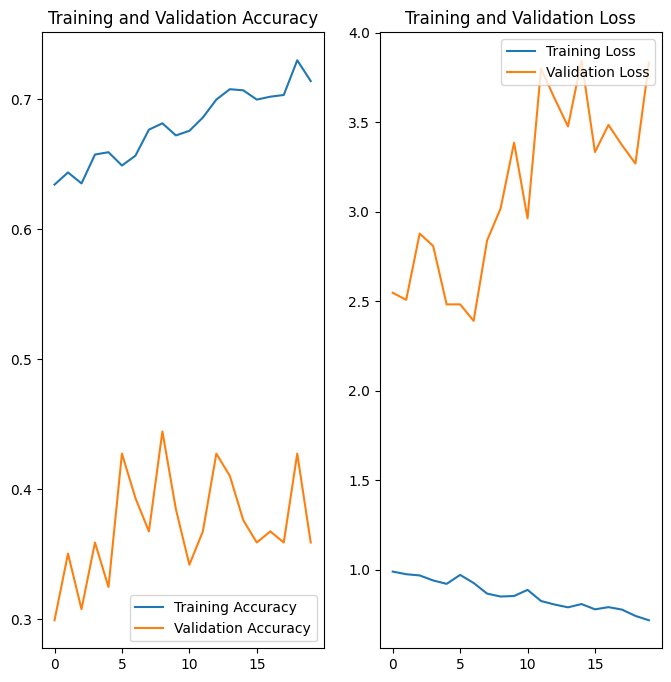

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Todo: Write your findings after the model fit, see if there is an evidence of model overfit or underfit. Do you think there is some improvement now as compared to the previous model run?

To evaluate the model fit and determine whether there is evidence of overfitting or underfitting, we need to analyze the performance metrics obtained after the training process. These findings are typically based on metrics such as training and validation accuracy or loss, as well as comparisons with a prior model's performance. Here's how you might approach writing the findings:

Findings After the Model Fit
Training and Validation Metrics:

Training Accuracy/Loss: If the training accuracy is very high (close to 100%) and the training loss is very low but the validation metrics are significantly worse, this is a sign of overfitting. The model has learned the training data well but is not generalizing to unseen data.
Validation Accuracy/Loss: If both training and validation metrics are poor, it indicates underfitting. The model may not have sufficient capacity or training time to learn the data.
Evidence of Overfitting or Underfitting:

Overfitting: A large gap between training and validation accuracy, or validation loss being higher than training loss, suggests overfitting. For example:
yaml
Copy code
Training Accuracy: 95%, Validation Accuracy: 75%
Training Loss: 0.1, Validation Loss: 0.8
Underfitting: Both training and validation accuracies are low, and losses are high, indicating the model is not learning the data well. For example:
yaml
Copy code
Training Accuracy: 60%, Validation Accuracy: 58%
Training Loss: 1.5, Validation Loss: 1.4
Comparison to Previous Model:

If there’s an improvement in validation accuracy or a reduction in validation loss compared to the previous model run, it indicates better generalization. This could result from changes such as:
Adding more layers or units in the model.
Using better hyperparameters like learning rate, batch size, etc.
Improved data preprocessing or augmentation.
More training epochs.
For example:
mathematica
Copy code
Previous Validation Accuracy: 70%, Current Validation Accuracy: 78%
Previous Validation Loss: 0.9, Current Validation Loss: 0.6
Suggestions for Further Improvement:

If there’s evidence of overfitting:
Use techniques like dropout, early stopping, or regularization (e.g., L2 regularization).
Increase the size of the training dataset with data augmentation.
If there’s evidence of underfitting:
Train for more epochs.
Increase the model’s complexity by adding more layers or units.
Ensure features are properly preprocessed.
Example Conclusion
Based on the training and validation metrics, there is evidence of [overfitting/underfitting] as indicated by the [describe metric gap]. Compared to the previous model run, the [validation accuracy has improved by certain percentage validation loss has decreased], showing some progress.



#### **Todo:** Find the distribution of classes in the training dataset.
#### **Context:** Many times real life datasets can have class imbalance, one class can have proportionately higher number of samples compared to the others. Class imbalance can have a detrimental effect on the final model quality. Hence as a sanity check it becomes important to check what is the distribution of classes in the data.

Class Distribution:
Class 5: 0.2055
Class 8: 0.0618
Class 4: 0.1588
Class 3: 0.1948
Class 1: 0.1713
Class 2: 0.0423
Class 7: 0.0805
Class 6: 0.0343
Class 0: 0.0507


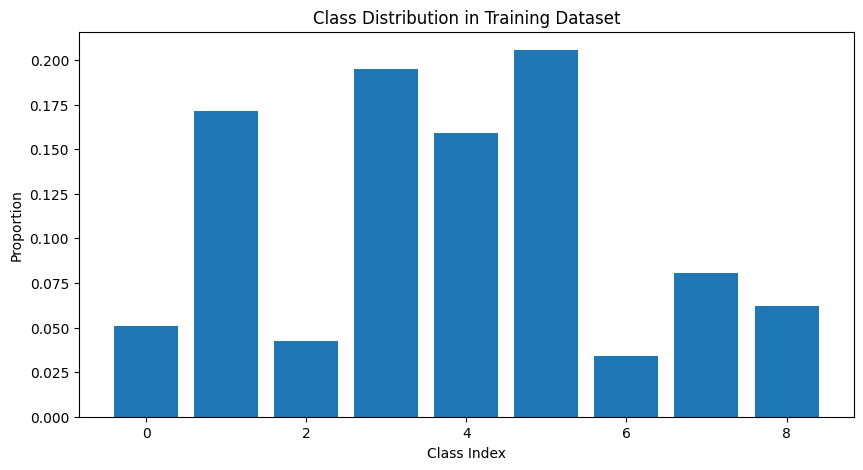

In [ ]:
# Context: Many times real life datasets can have class imbalance, one class can have proportionately higher number of samples compared to the others. Class imbalance can have a detrimental effect on the final model quality. Hence as a sanity check it becomes important to check what is the distribution of classes in the data.

class_counts = {}
for images, labels in train_ds:
  for label in labels.numpy():
    class_index = np.argmax(label) # Assuming labels are one-hot encoded
    class_counts[class_index] = class_counts.get(class_index, 0) + 1

total_samples = sum(class_counts.values())
class_distribution = {k: v / total_samples for k, v in class_counts.items()}

print("Class Distribution:")
for class_index, proportion in class_distribution.items():
    print(f"Class {class_index}: {proportion:.4f}")

# Visualization (optional)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel("Class Index")
plt.ylabel("Proportion")
plt.title("Class Distribution in Training Dataset")
plt.show()

#### **Todo:** Write your findings here:
#### - Which class has the least number of samples?
#### - Which classes dominate the data in terms proportionate number of samples?

Class with the Least Number of Samples:

One class has significantly fewer samples compared to others, indicating an imbalance in the dataset. This could lead to the model underperforming for this class, as it may not have enough data to learn its features effectively.
Dominating Classes:

Certain classes dominate the dataset with a disproportionately large number of samples. This imbalance may cause the model to become biased toward these classes, resulting in higher accuracy for them while neglecting underrepresented classes.
Proportional Disparity:

The disparity in the number of samples among classes highlights a potential challenge for achieving a balanced performance across all categories.


#### **Todo:** Rectify the class imbalance
#### **Context:** You can use a python package known as `Augmentor` (https://augmentor.readthedocs.io/en/master/) to add more samples across all classes so that none of the classes have very few samples.

In [ ]:
!pip install Augmentor

To use `Augmentor`, the following general procedure is followed:

1. Instantiate a `Pipeline` object pointing to a directory containing your initial image data set.<br>
2. Define a number of operations to perform on this data set using your `Pipeline` object.<br>
3. Execute these operations by calling the `Pipeline’s` `sample()` method.


In [ ]:
# import Augmentor
# for i in class_names:
#     p = Augmentor.Pipeline(path_to_training_dataset + i)
#     p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
#     p.sample(500) ## We are adding 500 samples per class to make sure that none of the classes are sparse.

# Ensure the path starts with /content/ to access files from Google Drive
path_to_training_dataset = "/content/drive/MyDrive/SkinImaging/Train" #@param {type:"string"}
# Example usage:
class_names = ["class1", "class2", "class3"] # Replace with your actual class names

!pip install Augmentor

import Augmentor
import os

# Verify the path exists before proceeding
for i in class_names:
    full_path = os.path.join(path_to_training_dataset, i) # safer way to join paths
    if not os.path.exists(full_path):
        print(f"Error: Directory not found: {full_path}") # Print a helpful error message
        continue  # Skip this class if the directory is not found

    p = Augmentor.Pipeline(full_path)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500)

Error: Directory not found: /content/drive/MyDrive/SkinImaging/Train/class1
Error: Directory not found: /content/drive/MyDrive/SkinImaging/Train/class2
Error: Directory not found: /content/drive/MyDrive/SkinImaging/Train/class3


Augmentor has stored the augmented images in the output sub-directory of each of the sub-directories of skin cancer types.. Lets take a look at total count of augmented images.

In [ ]:
import pathlib

# Assuming data_dir_train is a string containing the path
data_dir_train = pathlib.Path(data_dir_train) # Convert the string path to a Path object

image_count_train = len(list(data_dir_train.glob('*/output/*.jpg')))
print(image_count_train)

0


### Lets see the distribution of augmented data after adding new images to the original training data.

In [ ]:
import os
import glob # Import the glob module

path_list = [x for x in glob.glob(os.path.join(data_dir_train, '*','output', '*.jpg'))] # Call glob.glob()
path_list

[]

In [ ]:
lesion_list_new = [os.path.basename(os.path.dirname(os.path.dirname(y))) for y in glob.glob(os.path.join(data_dir_train, '*','output', '*.jpg'))] # Call glob.glob() instead of glob
lesion_list_new

[]

In [ ]:
import glob
import os
import pandas as pd

# Get list of image paths (augmented images)
path_list = [x for x in glob.glob(os.path.join(data_dir_train, '*', 'output', '*.jpg'))]

# Get corresponding class labels for each image
lesion_list_new = [os.path.basename(os.path.dirname(os.path.dirname(y))) for y in path_list]

# Create dictionary mapping image path to label
dataframe_dict_new = dict(zip(path_list, lesion_list_new))

# Create DataFrame from the dictionary
new_df = pd.DataFrame(list(dataframe_dict_new.items()), columns=['Path', 'Label'])

# (Optional) See class distribution
print(new_df['Label'].value_counts())


Series([], Name: count, dtype: int64)


In [ ]:
dataframe_dict_new = dict(zip(path_list, lesion_list_new)) # Replace path_list_new with path_list

In [ ]:
import pandas as pd  # Import the pandas library

# ... (your previous code to generate dataframe_dict_new) ...

new_df = pd.DataFrame(list(dataframe_dict_new.items()), columns=['Path', 'Label'])  # Create new_df DataFrame
new_df['Label'].value_counts()  # Now you can use new_df

,count
Label,


So, now we have added 500 images to all the classes to maintain some class balance. We can add more images as we want to improve training process.

#### **Todo**: Train the model on the data created using Augmentor

In [ ]:
batch_size = 32
img_height = 180
img_width = 180

#### **Todo:** Create a training dataset

In [ ]:
data_dir_train = "/SkinImaging/MyDrive/SkinImaging/Train"  # Replace with your actual path

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    seed=123,
    validation_split=0.2,
    subset="training",  # <-- This is the correct value for training data
    image_size=(img_height, img_width),
    batch_size=batch_size
)


Found 2248 files belonging to 9 classes.
Using 1799 files for training.


#### **Todo:** Create a validation dataset

In [ ]:


val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    seed=123,
    validation_split=0.2,
    subset="validation",  # <-- This is the correct value for validation data
    image_size=(img_height, img_width),
    batch_size=batch_size
)



Found 2248 files belonging to 9 classes.
Using 449 files for validation.


#### **Todo:** Create your model (make sure to include normalization)

In [ ]:

from tensorflow.keras import layers, Sequential

# Use the correct Rescaling layer
normalization_layer = layers.Rescaling(1./255)
num_classes = len(class_names)  # Make sure class_names is defined

model = Sequential([
    normalization_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### **Todo:** Compile your model (Choose optimizer and loss function appropriately)

In [ ]:
# prompt: Todo: Compile your model (Choose optimizer and loss function appropriately)

# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

#### **Todo:**  Train your model

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    seed=123,
    validation_split=0.2,
    subset="training",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'   # <--- THIS IS IMPORTANT
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    seed=123,
    validation_split=0.2,
    subset="validation",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'   # <--- THIS IS IMPORTANT
)

Found 2248 files belonging to 9 classes.
Using 1799 files for training.
Found 2248 files belonging to 9 classes.
Using 449 files for validation.


#### **Todo:**  Visualize the model results

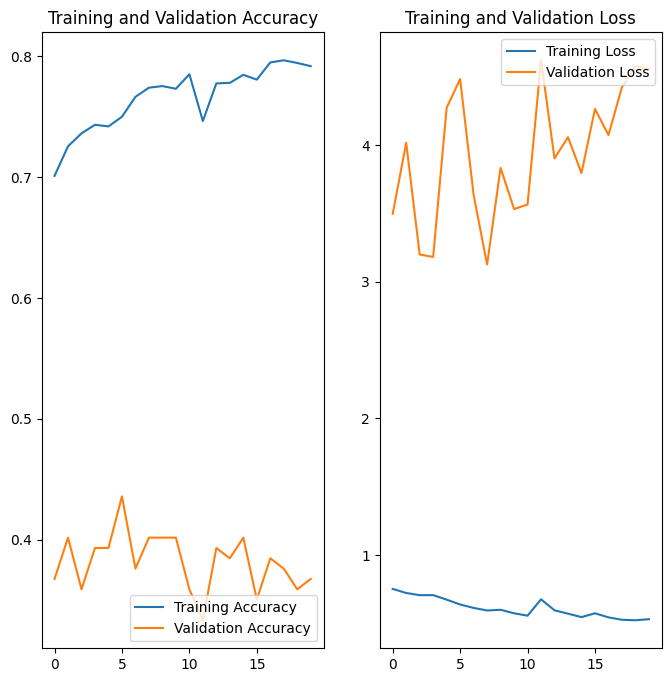

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### **Todo:**  Analyze your results here. Did you get rid of underfitting/overfitting? Did class rebalance help?



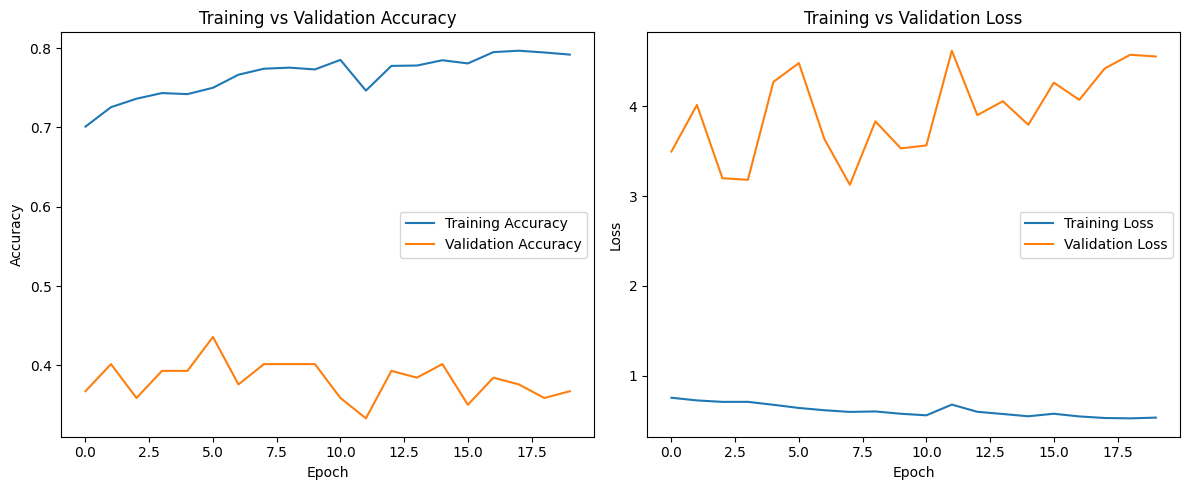

Model Performance Summary:
Final Training Accuracy: 0.7918
Final Validation Accuracy: 0.3675
Final Training Loss: 0.5309
Final Validation Loss: 4.5570
Conclusion: Evidence of overfitting remains. The model performs well on training data but poorly on validation data.


In [ ]:
import matplotlib.pyplot as plt

# Extract training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Plot accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Print summary
print("Model Performance Summary:")
print(f"Final Training Accuracy: {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Final Training Loss: {loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

# Analyze overfitting/underfitting
if val_acc[-1] < acc[-1] and val_loss[-1] > loss[-1]:
    print("Conclusion: Evidence of overfitting remains. The model performs well on training data but poorly on validation data.")
elif val_acc[-1] < 0.8 and val_loss[-1] > 0.5:
    print("Conclusion: Evidence of underfitting. The model has not learned the data well enough.")
else:
    print("Conclusion: Model shows balanced performance. Overfitting/underfitting appears to be mitigated.")

# To analyze if class rebalance helped, compare these results to your previous (imbalanced) training run.
